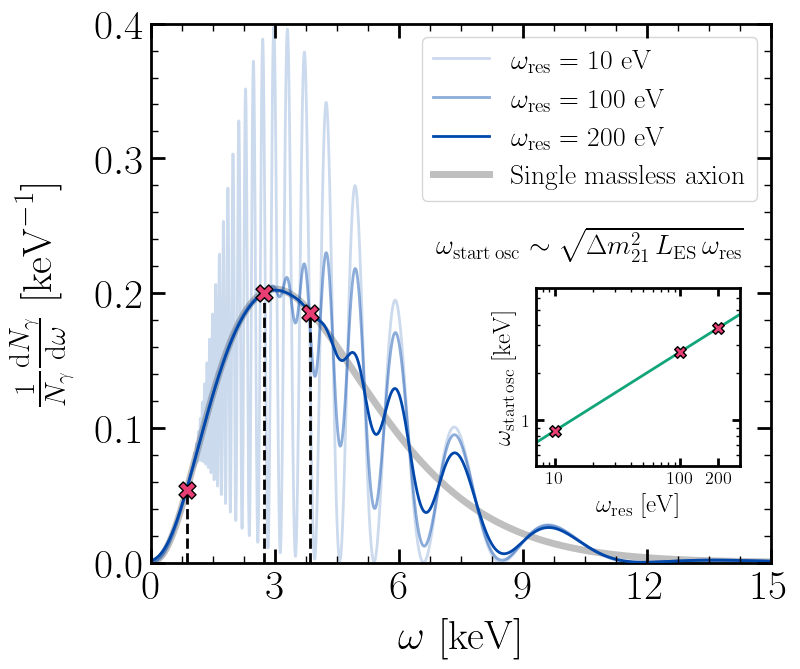

In [1]:
#%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
from palettable.colorbrewer.sequential import YlOrRd_5
from palettable.cartocolors.qualitative import Bold_10
from Functions_Binned_Analysis import dNdw, IAXO, L_ES, CFL
import os
os.environ['PATH'] = os.environ['PATH'] + ':/Library/TeX/texbin'

plt.rcParams.update({
   "text.usetex":True,
   "font.size":30,
   "axes.formatter.limits":[-3,3],
   "axes.linewidth":2,
   "lines.linewidth":2,
   "xtick.top":True,
   "xtick.bottom":True,
   "ytick.left":True,
   "ytick.right":True,
   "xtick.minor.visible":True,
   "ytick.minor.visible":True,
   "xtick.direction":"in",
   "ytick.direction":"in",
   "xtick.major.width":2,
   "xtick.minor.width":1,
   "ytick.major.width":2,
   "ytick.minor.width":1,
   "xtick.major.size":10,
   "xtick.minor.size":5,
   "ytick.major.size":10,
   "ytick.minor.size":5,
   "figure.figsize":[8,7],
   "savefig.dpi":300,
   "savefig.transparent":True
})

reds = YlOrRd_5.mpl_colors
bolds = Bold_10.mpl_colors

w_min = 0.0 # [keV]
w_max = 20.0 # [keV]
w = np.linspace(w_min,w_max,5000) # [keV]
g = 1e-11 # [GeV^-1]
m2 = 1e-3 # [eV]
delta_m21_sq = (7e-7)**2 # [eV^2]
delta_m21_sq_keV2 = delta_m21_sq*1e-6 # [keV^2]
mixing = np.pi/4.0
exp = IAXO
L_source = L_ES
L_source_keVinv = (L_source/CFL)*1e-6 # [keV^-1]
res_on = True

fig = plt.figure()
gs = gridspec.GridSpec(1,1,wspace=0)
ax = fig.add_subplot(gs[0])

# w_res = 10 eV
w_res = 10e-3 # [keV]
w_start_10eV = 0.75*np.sqrt(delta_m21_sq_keV2*L_source_keVinv*w_res/(2*np.sqrt(2)))
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
ax.plot(w,spectrum/N,label=r'$\omega_\mathrm{res} = 10\ \mathrm{eV}$',color="#0047AB",alpha=0.2)
ax.vlines(x=w_start_10eV,ymin=0,ymax=0.054,color='black',linestyle='--',lw=2,zorder=100)
ax.scatter(w_start_10eV,0.054,color=bolds[4],edgecolor='black',zorder=200,s=150,marker='X')

# w_res = 100 eV
w_res = 100e-3 # [keV]
w_start_100eV = 0.75*np.sqrt(delta_m21_sq_keV2*L_source_keVinv*w_res/(2*np.sqrt(2)))
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
ax.plot(w,spectrum/N,label=r'$\omega_\mathrm{res} = 100\ \mathrm{eV}$',color="#0047AB",alpha=0.45)
ax.vlines(x=w_start_100eV,ymin=0,ymax=0.2,color='black',linestyle='--',lw=2,zorder=100)
ax.scatter(w_start_100eV,0.2,color=bolds[4],edgecolor='black',zorder=200,s=150,marker='X')

# w_res = 200 eV
w_res = 200e-3 # [keV]
w_start_200eV = 0.75*np.sqrt(delta_m21_sq_keV2*L_source_keVinv*w_res/(2*np.sqrt(2)))
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
ax.plot(w,spectrum/N,label=r'$\omega_\mathrm{res} = 200\ \mathrm{eV}$',color="#0047AB",zorder=10)
ax.vlines(x=w_start_200eV,ymin=0,ymax=0.1852626,color='black',linestyle='--',lw=2,zorder=100)
ax.scatter(w_start_200eV,0.1852626,color=bolds[4],edgecolor='black',zorder=200,s=150,marker='X')

# 1-axion "massless"
delta_m21_sq = 0.0
mixing = 0.0
w_res = 100e-3 # [keV]
spectrum = dNdw(w,g,m2,delta_m21_sq,mixing,exp["B"],exp["L"],L_source,exp["S"],exp["t"],exp["eps_T"],exp["eps_D"],res_on=res_on,w_res=w_res)
N = np.trapezoid(spectrum,w)
ax.plot(w,spectrum/N,label=r'$\mathrm{Single\ massless\ axion}$',color='gray',lw=5,alpha=0.5,zorder=0)

ax.text(6.9,0.23,r'$\omega_\mathrm{start\, osc} \sim \sqrt{\Delta m_{21}^2\, L_\mathrm{ES}\, \omega_\mathrm{res}}$',fontsize=20)

ax.set_xlim(left=0,right=15)
ax.set_xticks([0,3,6,9,12,15])
ax.set_ylim(bottom=0,top=0.4)
ax.tick_params(axis='x',which='major',pad=5)
ax.tick_params(axis='x',which='minor',pad=5)
ax.tick_params(axis='y',which='major',pad=5)
ax.tick_params(axis='y',which='minor',pad=5)
ax.set_xlabel(r"$\omega\ [\mathrm{keV}]$",labelpad=8)
ax.set_ylabel(r"$\frac{1}{N_\gamma}\frac{\mathrm{d}N_\gamma}{\mathrm{d}\omega}\ [\mathrm{keV}^{-1}]$",labelpad=15)

ax.legend(fontsize=20,frameon=True)

# Inset
axins = ax.inset_axes([0.62,0.18,0.33,0.33])

w_res_vals_eV = np.logspace(0,3,300)   
w_res_vals_keV = w_res_vals_eV*1e-3
w_start_vals = 0.75*np.sqrt(delta_m21_sq_keV2*L_source_keVinv*w_res_vals_keV/(2*np.sqrt(2)))
axins.plot(w_res_vals_eV,w_start_vals,color=bolds[1],lw=2)

w_res_points_eV = np.array([10.0,100.0,200.0])
w_start_points = np.array([w_start_10eV,w_start_100eV,w_start_200eV])

axins.scatter(w_res_points_eV[0],w_start_points[0],color=bolds[4],edgecolor='black',s=70,marker='X',zorder=10)
axins.scatter(w_res_points_eV[1],w_start_points[1],color=bolds[4],edgecolor='black',s=70,marker='X',zorder=10)
axins.scatter(w_res_points_eV[2],w_start_points[2],color=bolds[4],edgecolor='black',s=70,marker='X',zorder=10)

axins.set_xscale('log')
axins.set_yscale('log')

axins.set_xlabel(r'$\omega_\mathrm{res}\ [\mathrm{eV}]$',fontsize=18,labelpad=4)
axins.set_ylabel(r'$\omega_\mathrm{start\,osc}\ [\mathrm{keV}]$',fontsize=18,labelpad=4)

axins.tick_params(axis='both',which='major',labelsize=13,length=6,width=2)
axins.tick_params(axis='both',which='minor',labelsize=0,length=3,width=1)

axins.yaxis.set_major_formatter(ScalarFormatter())
axins.yaxis.get_major_formatter().set_scientific(False)
axins.set_xticks([10,100,200])
axins.set_yticks([1])
axins.get_xaxis().set_major_formatter(plt.ScalarFormatter())

axins.set_xlim(7,300)
axins.set_ylim(0.6*w_start_10eV,1.8*w_start_200eV)

for spine in axins.spines.values():
    spine.set_linewidth(2)

ax.xaxis.set_zorder(1000)
ax.yaxis.set_zorder(1000)

fig.savefig("plots/Resolution.pdf",bbox_inches="tight")
fig.savefig("plots/Resolution.png",bbox_inches="tight")
plt.show()